# Proyecto Final 4Geeks - FAOSTAT

Proyecto ejecutado de punta a punta con datos públicos de FAOSTAT. Este notebook documenta la definición del problema, la obtención de datos, el almacenamiento en SQLite, el análisis descriptivo/EDA, el entrenamiento del modelo y la app de despliegue.

## Paso 1: Definición del problema

**Problema de negocio:** estimar el valor esperado de bioenergía por país, año, ítem y tipo de medición para apoyar decisiones de inversión e investigación agroalimentaria.

La fuente solicitada fue `https://www.fao.org/faostat/en/#data/AF`. En el catálogo oficial de FAOSTAT, `AF` corresponde a **ASTI - Researchers**. Como este dominio es pequeño para el requisito de 60.000 filas, se usa como fuente contextual y se combina con otros dominios FAOSTAT relacionados:

- `AF`: investigadores ASTI, fuente solicitada.
- `AE`: gasto en investigación agrícola.
- `CISP`: inversión y valor agregado agropecuario.
- `BE`: bioenergía, tabla principal del modelo.

**Variable objetivo:** `target_value`, valor histórico de producción o consumo de bioenergía. Para el modelo se usa `log_target_value = log1p(target_value)` para reducir el peso de valores extremos.

In [33]:
import json
import sqlite3
import sys
from pathlib import Path, PurePosixPath

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.model_selection import train_test_split

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SAFE_ROOT = PurePosixPath("/workspace/Proyecto-Final-4geeks-bioenergia-sector-agroalimentario")


def safe_path(path):
    """Muestra rutas neutrales sin exponer la ruta local del equipo."""
    path = Path(path)
    try:
        rel = path.resolve().relative_to(ROOT.resolve())
        return str(SAFE_ROOT / PurePosixPath(*rel.parts))
    except ValueError:
        return str(SAFE_ROOT / path.name)


sys.path.append(str(ROOT / "src"))

from config import DATABASE_PATH, METADATA_PATH, MODELING_DATA_PATH, MODEL_PATH
from data_download import DATASETS, download_all, load_raw_frames
from database import run_example_queries, store_database
from eda import run_eda
from features import build_modeling_dataset
from train_model import train

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:,.3f}".format)
SAFE_ROOT

PurePosixPath('/workspace/Proyecto-Final-4geeks-bioenergia-sector-agroalimentario')

## Paso 2: Obtención y carga del conjunto de datos

Los datos se obtienen desde descargas bulk oficiales de FAOSTAT. El pipeline guarda los ZIP originales en `data/raw/` y luego los carga con Pandas.

In [34]:
download_all(skip_if_present=True)
frames = load_raw_frames()

source_summary = pd.DataFrame([
    {
        "codigo": code,
        "nombre": DATASETS[code]["name"],
        "rol": DATASETS[code]["role"],
        "filas": frame.shape[0],
        "columnas": frame.shape[1],
    }
    for code, frame in frames.items()
])
source_summary

,codigo,nombre,rol,filas,columnas
0,AF,ASTI - Researchers,requested_source,3800,20
1,AE,ASTI - Expenditures,context,7789,17
2,BE,Bioenergy,model_base,122374,14
3,CISP,Country Investment Statistics Profile,context,66447,15


## Paso 3: Almacenar la información en SQLite

Se crea una base SQLite con las tablas crudas y una tabla final de modelado. También se ejecutan consultas SQL con `SELECT`, `JOIN`, agregaciones e `INSERT` para demostrar almacenamiento y explotación de la base.

In [35]:
modeling = build_modeling_dataset(frames)
db_path = store_database(frames, modeling)

print(f"Base SQLite creada en: {safe_path(db_path)}")
print(f"Dataset final: {modeling.shape[0]:,} filas x {modeling.shape[1]:,} columnas")
modeling.head()

Base SQLite creada en: /workspace/Proyecto-Final-4geeks-bioenergia-sector-agroalimentario/data/database/faostat_project.db
Dataset final: 101,995 filas x 29 columnas


,area_key,area,item,element,unit,year,target_value,item_code,element_code,flag,af_value,ae_value,cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_agriculture_orientation_index_us,cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_share_of_total_us,cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_value_us_2023_prices,cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_agriculture_orientatio,cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_share_of_total_us_2015,cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_share_of_value_added_u,cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_value_us_2015_prices,cisp_value_added_agriculture_forestry_and_fishing_annual_growth_us_2015_prices,cisp_value_added_agriculture_forestry_and_fishing_share_of_total_us_2015_prices,cisp_value_added_agriculture_forestry_and_fishing_value_us_2015_prices,target_lag_1,target_lag_2,target_lag_3,target_roll_mean_3,year_since_1990,log_target_value,has_asti_context
0,'001,World,Animal waste,Energy consumption,TJ,1990,"125,022.962",6519,5851,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,11.736,0
1,'001,World,Animal waste,Energy consumption,TJ,1991,"124,374.750",6519,5851,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"125,022.962",NaN,NaN,"125,022.962",1,11.731,0
2,'001,World,Animal waste,Energy consumption,TJ,1992,"129,583.912",6519,5851,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"124,374.750","125,022.962",NaN,"124,698.856",2,11.772,0
3,'001,World,Animal waste,Energy consumption,TJ,1993,"132,484.296",6519,5851,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"129,583.912","124,374.750","125,022.962","126,327.208",3,11.794,0
4,'001,World,Animal waste,Energy consumption,TJ,1994,"220,653.224",6519,5851,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"132,484.296","129,583.912","124,374.750","128,814.319",4,12.304,0


In [36]:
with sqlite3.connect(DATABASE_PATH) as conn:
    tables = pd.read_sql_query("""
        SELECT name AS tabla
        FROM sqlite_master
        WHERE type = 'table'
        ORDER BY name
    """, conn)

tables

,tabla
0,modeling_bioenergy
1,project_notes
2,raw_ae
3,raw_af
4,raw_be
5,raw_cisp
6,sqlite_sequence


In [37]:
queries = run_example_queries()
queries["select_top_bioenergy"]

,area,item,element,year,unit,target_value
0,World,Total Bioenergy,Energy production,2023,TJ,"49,649,777.821"
1,World,Total Bioenergy,Energy production,2022,TJ,"49,249,521.252"
2,World,Total Bioenergy,Energy production,2021,TJ,"48,834,808.458"
3,World,Total Bioenergy,Energy production,2019,TJ,"47,600,276.009"
4,World,Total Bioenergy,Energy production,2020,TJ,"47,277,121.662"
5,World,Total Bioenergy,Energy production,2018,TJ,"47,236,838.919"
6,World,Total Bioenergy,Energy production,2017,TJ,"46,202,523.428"
7,World,Total Bioenergy,Energy production,2016,TJ,"45,502,367.582"
8,World,Total Bioenergy,Energy production,2015,TJ,"44,515,778.663"
9,World,Total Bioenergy,Energy production,2014,TJ,"44,069,611.062"


In [38]:
queries["join_be_af"].head(10)

,area,year,item,element,target_value,asti_research_context
0,Afghanistan,1990,Charcoal,Energy consumption,"1,150.323",None
1,Afghanistan,1990,Charcoal,Energy production,"1,150.323",None
2,Afghanistan,1990,Fuelwood,Energy consumption,"4,176.997",None
3,Afghanistan,1990,Fuelwood,Energy production,"6,314.258",None
4,Afghanistan,1990,Solid biofuels,Energy consumption,"5,327.320",None
5,Afghanistan,1990,Solid biofuels,Energy production,"6,314.258",None
6,Afghanistan,1990,Total Bioenergy,Energy consumption,"5,327.320",None
7,Afghanistan,1990,Total Bioenergy,Energy production,"6,314.258",None
8,Afghanistan,1991,Charcoal,Energy consumption,"1,190.236",None
9,Afghanistan,1991,Charcoal,Energy production,"1,190.236",None


## Paso 4: Análisis descriptivo

Se revisan dimensiones, tipos de variables, nulos y medidas estadísticas de la variable objetivo. El dataset supera el mínimo solicitado: más de 60.000 filas y más de 20 predictores, con variables categóricas.

In [39]:
summary = run_eda(modeling)
summary

{'rows': 101995,
 'columns': 29,
 'numeric_predictors': 19,
 'categorical_predictors': 8,
 'target_mean': 447212.7152551684,
 'target_median': 11815.2,
 'target_std': 2193562.0872654896,
 'missing_rate': 0.192605114179025}

In [40]:
predictor_count = len([c for c in modeling.columns if c not in ["target_value", "log_target_value", "flag", "flag_description"]])
categorical_predictors = modeling.select_dtypes(include=["object", "string"]).columns.tolist()

pd.DataFrame({
    "indicador": ["filas", "columnas", "predictores", "variables_categoricas"],
    "valor": [modeling.shape[0], modeling.shape[1], predictor_count, len(categorical_predictors)]
})

,indicador,valor
0,filas,101995
1,columnas,29
2,predictores,26
3,variables_categoricas,8


In [41]:
modeling[["target_value", "log_target_value", "year", "target_lag_1", "target_roll_mean_3"]].describe().T

,count,mean,std,min,25%,50%,75%,max
target_value,"101,995.000","447,212.715","2,193,562.087",0.000,788.523,"11,815.200","106,215.000","49,649,777.821"
log_target_value,"101,995.000",9.020,3.547,0.000,6.671,9.377,11.573,17.721
year,"101,995.000","2,007.752",9.645,"1,990.000","2,000.000","2,008.000","2,016.000","2,023.000"
target_lag_1,"98,277.000","446,417.216","2,184,391.461",0.000,800.988,"11,918.000","106,755.262","49,249,521.252"
target_roll_mean_3,"98,277.000","439,032.608","2,154,299.470",0.000,786.318,"11,582.667","103,696.667","48,453,817.124"


In [42]:
modeling.select_dtypes(include=["object", "string"]).nunique().sort_values(ascending=False).to_frame("valores_unicos")

,valores_unicos
area_key,270
area,270
item,15
item_code,15
flag,3
element,2
element_code,2
unit,1


## Diccionario de datos

Descripción de cada columna del dataset final de modelado (101.995 filas × 29 columnas).

In [43]:
data_dictionary = {
    # --- Identificadores ---
    "area_key":     "Código interno FAOSTAT del área geográfica. Clave de join entre datasets.",
    "area":         "País, región o agrupación geopolítica. 270 valores únicos (países + agregados como SIDS, World).",
    "item":         "Tipo de fuente de bioenergía (15 valores: Fuelwood, Charcoal, Biodiesel, Biogas, etc.).",
    "item_code":    "Código numérico FAOSTAT del ítem. Equivalente entero de 'item'.",
    "element":      "Tipo de medición: 'Energy production' o 'Energy consumption'.",
    "element_code": "Código numérico del element (5851=consumo, 5852=producción).",
    "unit":         "Unidad de medida energética. Constante: siempre 'TJ' (Terajulios).",
    "flag":         "Calidad del dato FAOSTAT: E=Estimado, F=Calculado por FAO, A=Oficial.",
    # --- Variable objetivo ---
    "target_value":     "Valor de bioenergía en TJ. Variable a predecir. Alta asimetría (media≈447k, mediana≈12k).",
    "log_target_value": "log1p(target_value). Variable objetivo usada en el modelo para reducir el efecto de outliers.",
    # --- Tiempo ---
    "year":             "Año de la observación. Rango 1990–2023.",
    "year_since_1990":  "Años transcurridos desde 1990. Versión centrada de 'year'.",
    # --- Features temporales (engineered) ---
    "target_lag_1":       "Valor de bioenergía del año anterior (misma serie país–ítem–elemento).",
    "target_lag_2":       "Valor de bioenergía de hace 2 años.",
    "target_lag_3":       "Valor de bioenergía de hace 3 años.",
    "target_roll_mean_3": "Media móvil de los 3 años anteriores. Suaviza tendencia de corto plazo.",
    # --- ASTI (investigación agrícola) ---
    "af_value":          "Investigadores agrícolas FTE por país-año. Fuente: ASTI-AF.",
    "ae_value":          "Gasto en investigación agrícola (miles PPP USD 2011). Fuente: ASTI-AE.",
    "has_asti_context":  "Binaria: 1 si el país-año tiene datos ASTI disponibles, 0 si no.",
    # --- CISP (inversión agrícola) ---
    "cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_agriculture_orientation_index_us":
        "Índice de orientación agrícola de la AOD (Ayuda Oficial al Desarrollo) hacia el sector.",
    "cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_share_of_total_us":
        "% de la AOD total destinado a agricultura, silvicultura y pesca.",
    "cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_value_us_2023_prices":
        "Valor absoluto de la AOD a agricultura en M USD constantes 2023.",
    "cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_agriculture_orientatio":
        "Índice de orientación agrícola de la Formación Bruta de Capital Fijo (FBCF).",
    "cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_share_of_total_us_2015":
        "% de la FBCF total invertido en agricultura (precios constantes 2015).",
    "cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_share_of_value_added_u":
        "Ratio FBCF agrícola / valor añadido agrícola. Mide la tasa de reinversión del sector.",
    "cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_value_us_2015_prices":
        "Valor absoluto de la FBCF agrícola en M USD constantes 2015.",
    "cisp_value_added_agriculture_forestry_and_fishing_annual_growth_us_2015_prices":
        "Tasa de crecimiento anual (%) del valor añadido agrícola. Puede ser negativa.",
    "cisp_value_added_agriculture_forestry_and_fishing_share_of_total_us_2015_prices":
        "Participación del sector agrícola en el PIB total (%).",
    "cisp_value_added_agriculture_forestry_and_fishing_value_us_2015_prices":
        "Valor añadido del sector agricultura, silvicultura y pesca en M USD constantes 2015.",
}

pd.DataFrame(
    {"columna": list(data_dictionary.keys()), "descripcion": list(data_dictionary.values())}
)

,columna,descripcion
0,area_key,Código interno FAOSTAT del área geográfica. Cl...
1,area,"País, región o agrupación geopolítica. 270 val..."
2,item,Tipo de fuente de bioenergía (15 valores: Fuel...
3,item_code,Código numérico FAOSTAT del ítem. Equivalente ...
4,element,Tipo de medición: 'Energy production' o 'Energ...
5,element_code,"Código numérico del element (5851=consumo, 585..."
6,unit,Unidad de medida energética. Constante: siempr...
7,flag,"Calidad del dato FAOSTAT: E=Estimado, F=Calcul..."
8,target_value,Valor de bioenergía en TJ. Variable a predecir...
9,log_target_value,log1p(target_value). Variable objetivo usada e...


## Diccionario de términos del proyecto

Aclaración rápida de la terminología técnica y de dominio usada en este notebook,
para que cualquier persona que lo lea pueda seguir el flujo sin buscar definiciones externas.


In [44]:
glossary = {
    # --- Métricas de evaluación del modelo ---
    "R² (R-cuadrado)":            "Coeficiente de determinación. Mide qué porcentaje de la variabilidad del objetivo explica el modelo. 1.0 = predicción perfecta, 0 = no mejor que la media.",
    "MAE":                        "Mean Absolute Error. Error absoluto medio en las unidades originales (TJ). Robusto a outliers.",
    "RMSE":                       "Root Mean Squared Error. Raíz del error cuadrático medio. Penaliza más los errores grandes que MAE.",
    "log1p / expm1":              "log1p(x) = ln(1 + x), su inversa es expm1(y) = exp(y) - 1. Se usa para comprimir valores extremos antes de entrenar y luego volver al valor real.",

    # --- Estadística ---
    "Kruskal-Wallis":             "Test no paramétrico que compara medianas entre 3+ grupos. Se usa porque la bioenergía es muy asimétrica (no normal).",
    "Correlación de Pearson":     "Mide relación lineal entre dos variables numéricas. Valores cerca de ±1 = fuerte; cerca de 0 = sin relación lineal.",
    "Sesgo / asimetría (skew)":   "Mide cuánto se desvía la distribución de la simetría. Bioenergía tiene sesgo positivo (cola larga a la derecha).",
    "Curtosis":                   "Mide el grosor de las colas. Curtosis alta = más valores extremos de lo esperado en una normal.",
    "Multicolinealidad":          "Dos o más predictores muy correlacionados entre sí. Confunde al modelo y reduce interpretabilidad.",
    "Data Leakage (fuga de datos)": "El modelo accede durante el entrenamiento a información que no tendría en producción (ej. el valor a predecir disfrazado de feature).",

    # --- Modelo y entrenamiento ---
    "HistGradientBoostingRegressor": "Modelo de boosting basado en histogramas. Versión rápida de Gradient Boosting. Bueno para datos tabulares con variables mixtas.",
    "GridSearchCV":                "Búsqueda exhaustiva de hiperparámetros validada con K-fold cross-validation.",
    "Hiperparámetros":             "Parámetros que controlan el aprendizaje del modelo (no se aprenden de los datos): learning_rate, max_iter, max_leaf_nodes, etc.",
    "Split temporal train/test":   "División cronológica: el modelo entrena con años antiguos y se evalúa con años recientes, simulando el escenario real.",
    "ColumnTransformer":           "Utilidad de scikit-learn que aplica transformaciones distintas a columnas distintas (numéricas vs categóricas).",
    "Codificación ordinal":        "Convierte categorías de texto en enteros para que el modelo pueda procesarlas.",
    "Imputación de nulos":         "Rellenar valores faltantes (NaN) con la mediana, media o un valor constante antes de entrenar.",

    # --- Feature engineering temporal ---
    "Lag (rezago)":                "Valor de la misma serie en un período anterior. lag_1 = año pasado, lag_2 = hace 2 años, etc.",
    "Media móvil (rolling mean)":  "Promedio de los últimos N valores. Suaviza el ruido y captura tendencia.",
    "year_since_1990":             "Variable temporal numérica = year - 1990. Versión centrada para facilitar el aprendizaje.",

    # --- FAOSTAT y dominio agroalimentario ---
    "FAOSTAT":                     "Base de datos estadísticos de la FAO (Food and Agriculture Organization). Datos públicos sobre agricultura, comercio, recursos, etc.",
    "AF (ASTI Researchers)":       "Dominio FAOSTAT con número de investigadores en I+D agrícola por país-año. Fuente solicitada por la entrega.",
    "AE (ASTI Expenditures)":      "Dominio FAOSTAT con el gasto en I+D agrícola por país-año (precios PPP 2011).",
    "ASTI":                        "Agricultural Science and Technology Indicators — sistema internacional que mide ciencia y tecnología agrícola.",
    "CISP":                        "Country Investment Statistics Profile — perfil de inversión agrícola por país (FBCF, valor añadido, AOD).",
    "BE (Bioenergy)":              "Dominio FAOSTAT con producción y consumo de bioenergía por país, ítem y elemento. Tabla principal del modelado.",
    "TJ (Terajulios)":             "Unidad de energía. 1 TJ = 10¹² julios ≈ 277,8 MWh ≈ 23,9 toneladas equivalentes de petróleo.",
    "FBCF":                        "Formación Bruta de Capital Fijo. Inversión en activos productivos duraderos (maquinaria, infraestructura).",
    "AOD":                         "Ayuda Oficial al Desarrollo. Flujos de financiación de donantes hacia países receptores con fines de desarrollo.",
    "Bulk download":               "Descarga masiva del dataset completo desde FAOSTAT en formato ZIP (vs consultar registro a registro vía API).",

    # --- Estructura del proyecto ---
    "Pipeline":                    "Cadena automática que descarga datos → procesa → guarda en BBDD → hace EDA → entrena modelo. Aquí está en src/run_pipeline.py.",
    "Target / objetivo":           "Variable que se quiere predecir. En este proyecto: el valor de bioenergía (target_value en TJ).",
    "Predictor / feature":         "Variable de entrada usada por el modelo para predecir el objetivo.",
    "EDA":                         "Exploratory Data Analysis. Análisis descriptivo y visual previo al modelado.",
    "SQLite":                      "Motor de base de datos ligero, basado en un único archivo. Usado aquí para almacenar tablas crudas y dataset final.",
    "Streamlit":                   "Framework Python para construir aplicaciones web interactivas de Data Science con poco código.",
    "Render":                      "Plataforma cloud (PaaS) para desplegar apps web. Configurado en render.yaml.",
}

pd.DataFrame(
    {"término": list(glossary.keys()), "definición": list(glossary.values())}
)


,término,definición
0,R² (R-cuadrado),Coeficiente de determinación. Mide qué porcent...
1,MAE,Mean Absolute Error. Error absoluto medio en l...
2,RMSE,Root Mean Squared Error. Raíz del error cuadrá...
3,log1p / expm1,"log1p(x) = ln(1 + x), su inversa es expm1(y) =..."
4,Kruskal-Wallis,Test no paramétrico que compara medianas entre...
5,Correlación de Pearson,Mide relación lineal entre dos variables numér...
6,Sesgo / asimetría (skew),Mide cuánto se desvía la distribución de la si...
7,Curtosis,Mide el grosor de las colas. Curtosis alta = m...
8,Multicolinealidad,Dos o más predictores muy correlacionados entr...
9,Data Leakage (fuga de datos),El modelo accede durante el entrenamiento a in...


### Distribución de predictores y contraste de hipótesis

Para cubrir el análisis descriptivo de las predictoras, se calcula una lectura automática de distribución para cada variable numérica: media, mediana, desviación, sesgo, curtosis y una interpretación simple. También se realiza un contraste de hipótesis para validar si existen diferencias estadísticamente significativas en el valor de bioenergía entre tipos de `item`.

- **H0:** la distribución del valor objetivo es similar entre grupos de `item`.
- **H1:** al menos un grupo de `item` presenta diferencias relevantes.
- Se usa Kruskal-Wallis porque el objetivo es muy asimétrico y no conviene asumir normalidad.

In [45]:
numeric_predictors = [
    col for col in modeling.select_dtypes(include="number").columns
    if col not in ["target_value", "log_target_value"]
]

distribution_rows = []
for col in numeric_predictors:
    series = pd.to_numeric(modeling[col], errors="coerce").dropna()
    if series.empty:
        continue
    skewness = series.skew()
    if abs(skewness) < 0.5:
        interpretation = "aprox. simetrica"
    elif skewness > 0:
        interpretation = "asimetrica positiva"
    else:
        interpretation = "asimetrica negativa"
    distribution_rows.append({
        "predictora": col,
        "n": len(series),
        "media": series.mean(),
        "mediana": series.median(),
        "desv_std": series.std(),
        "min": series.min(),
        "max": series.max(),
        "sesgo": skewness,
        "curtosis": series.kurtosis(),
        "lectura_distribucion": interpretation,
    })

distribution_table = pd.DataFrame(distribution_rows).sort_values("predictora")
distribution_table

,predictora,n,media,mediana,desv_std,min,max,sesgo,curtosis,lectura_distribucion
2,ae_value,28533,"27,076.050","1,635.402","137,078.344",0.180,"1,313,874.331",7.325,57.174,asimetrica positiva
1,af_value,28786,"7,818.422","1,215.450","19,509.377",4.000,"158,196.050",4.947,27.790,asimetrica positiva
3,cisp_dfa_disbursement_to_agriculture_forestry_...,47145,0.598,0.340,1.428,0.000,44.896,13.963,301.855,asimetrica positiva
4,cisp_dfa_disbursement_to_agriculture_forestry_...,47605,5.175,4.292,5.083,0.000,82.928,5.179,48.335,asimetrica positiva
5,cisp_dfa_disbursement_to_agriculture_forestry_...,47605,525.683,52.168,"1,585.265",0.000,"18,221.096",5.873,43.949,asimetrica positiva
6,cisp_gross_fixed_capital_formation_agriculture...,67757,0.859,0.547,0.868,0.011,13.022,4.740,44.021,asimetrica positiva
7,cisp_gross_fixed_capital_formation_agriculture...,67757,4.846,3.504,4.765,0.030,89.327,4.491,44.274,asimetrica positiva
8,cisp_gross_fixed_capital_formation_agriculture...,67757,18.511,12.808,17.827,0.152,247.041,3.978,31.720,asimetrica positiva
9,cisp_gross_fixed_capital_formation_agriculture...,67757,"16,473.740","1,198.637","56,402.832",0.027,"683,856.096",6.810,54.963,asimetrica positiva
10,cisp_value_added_agriculture_forestry_and_fish...,69818,2.287,2.571,8.899,-71.865,123.420,1.178,17.569,asimetrica positiva


In [46]:
from scipy.stats import kruskal

sample_for_test = modeling[["item", "target_value"]].dropna()
item_groups = [
    group["target_value"].sample(min(len(group), 3000), random_state=42)
    for _, group in sample_for_test.groupby("item")
    if len(group) >= 30
]

statistic, p_value = kruskal(*item_groups)
alpha = 0.05
pd.DataFrame({
    "contraste": ["Kruskal-Wallis por item"],
    "estadistico": [statistic],
    "p_value": [p_value],
    "alpha": [alpha],
    "decision": ["rechazar H0" if p_value < alpha else "no rechazar H0"],
    "interpretacion": [
        "El valor de bioenergia cambia significativamente segun el item."
        if p_value < alpha
        else "No hay evidencia suficiente de diferencias por item."
    ],
})

,contraste,estadistico,p_value,alpha,decision,interpretacion
0,Kruskal-Wallis por item,"4,860.412",0.000,0.050,rechazar H0,El valor de bioenergia cambia significativamen...


## Paso 5: EDA completo

Los gráficos principales se guardan en `reports/figures/` y quedan renderizados aquí para revisar tendencias, ítems dominantes y valores nulos.

bioenergy_trend.png


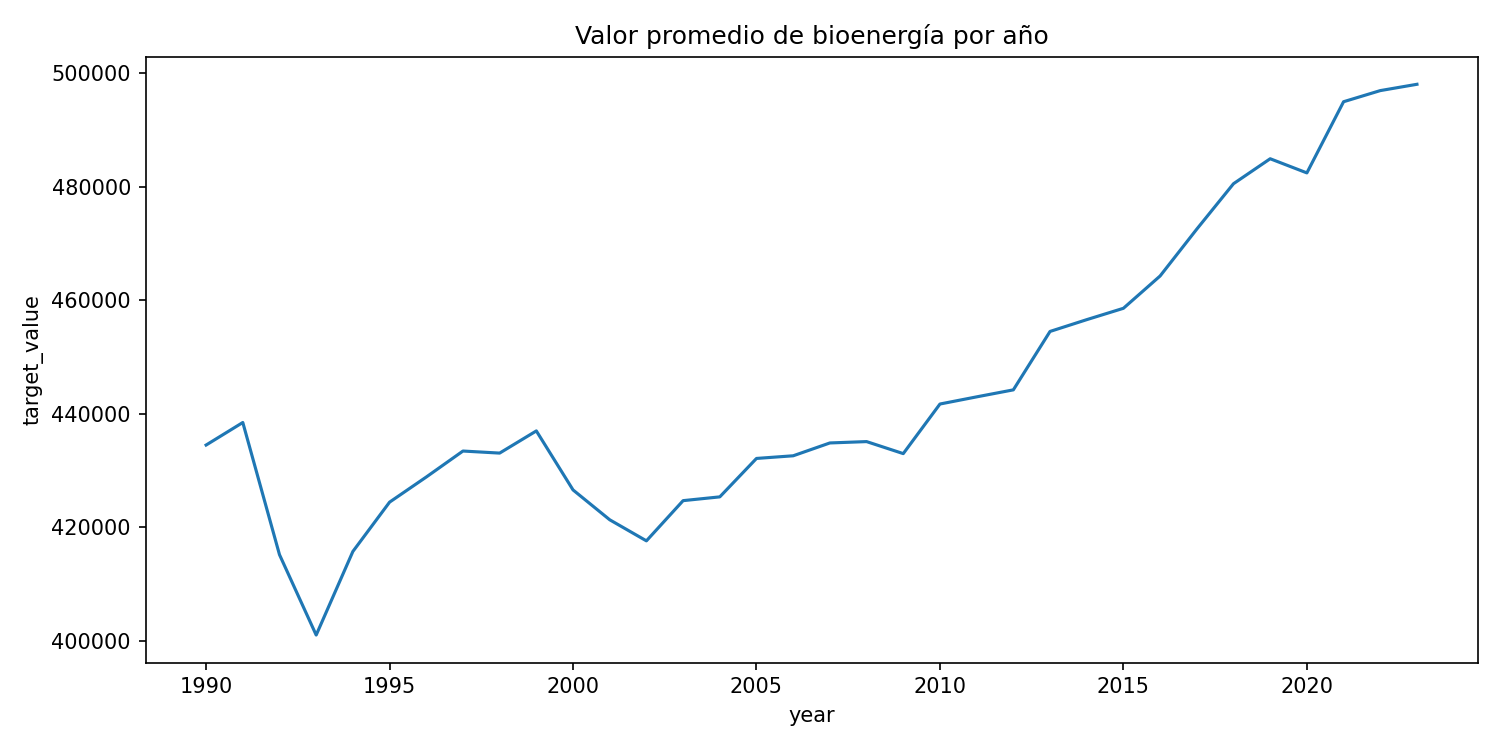

top_items.png


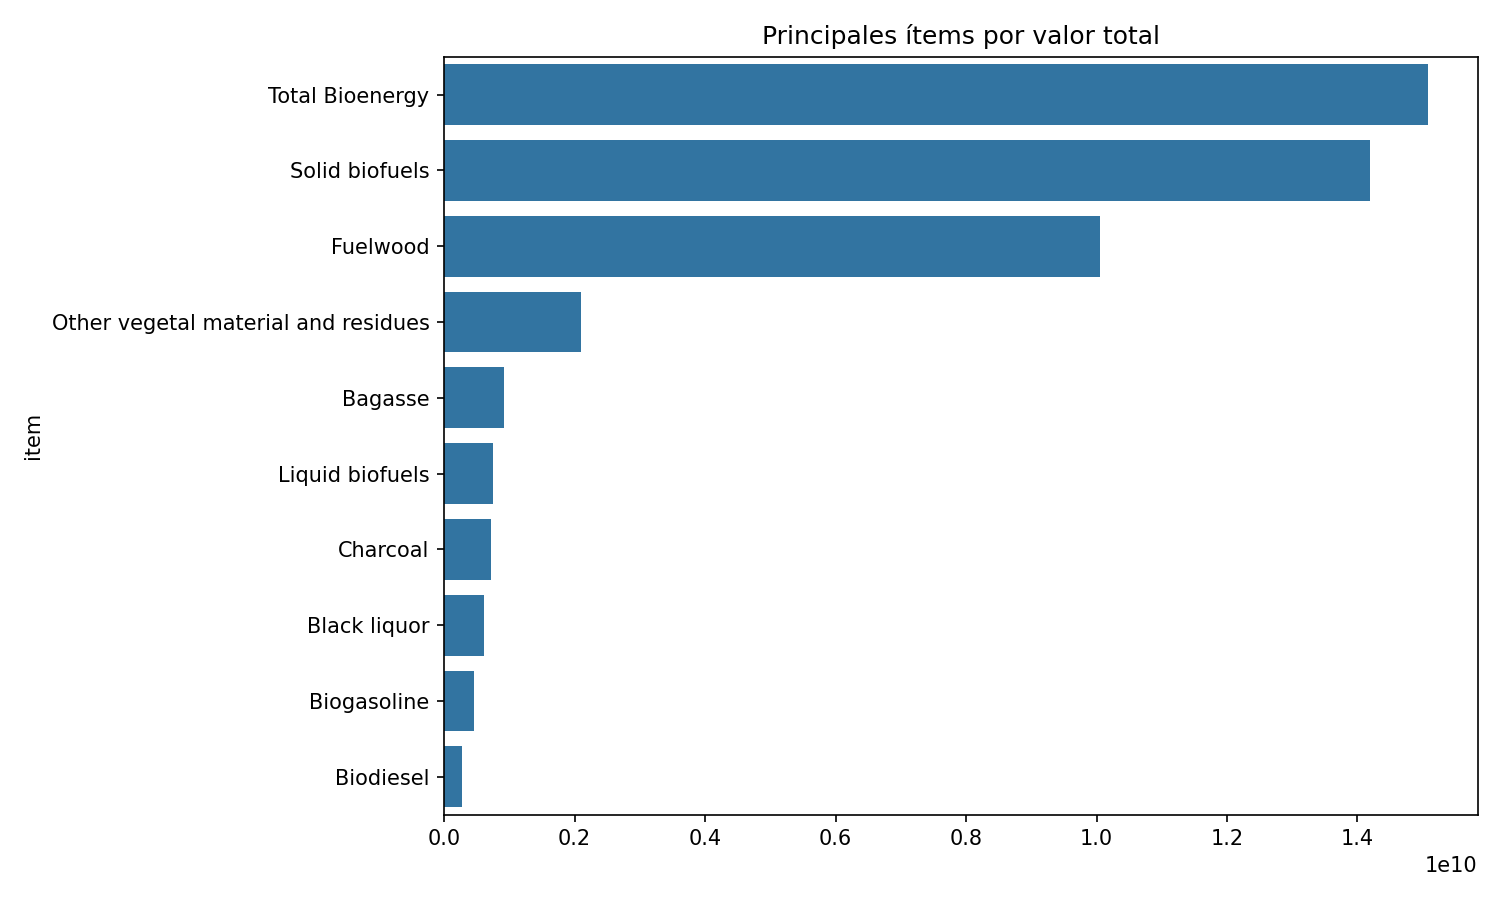

missing_values.png


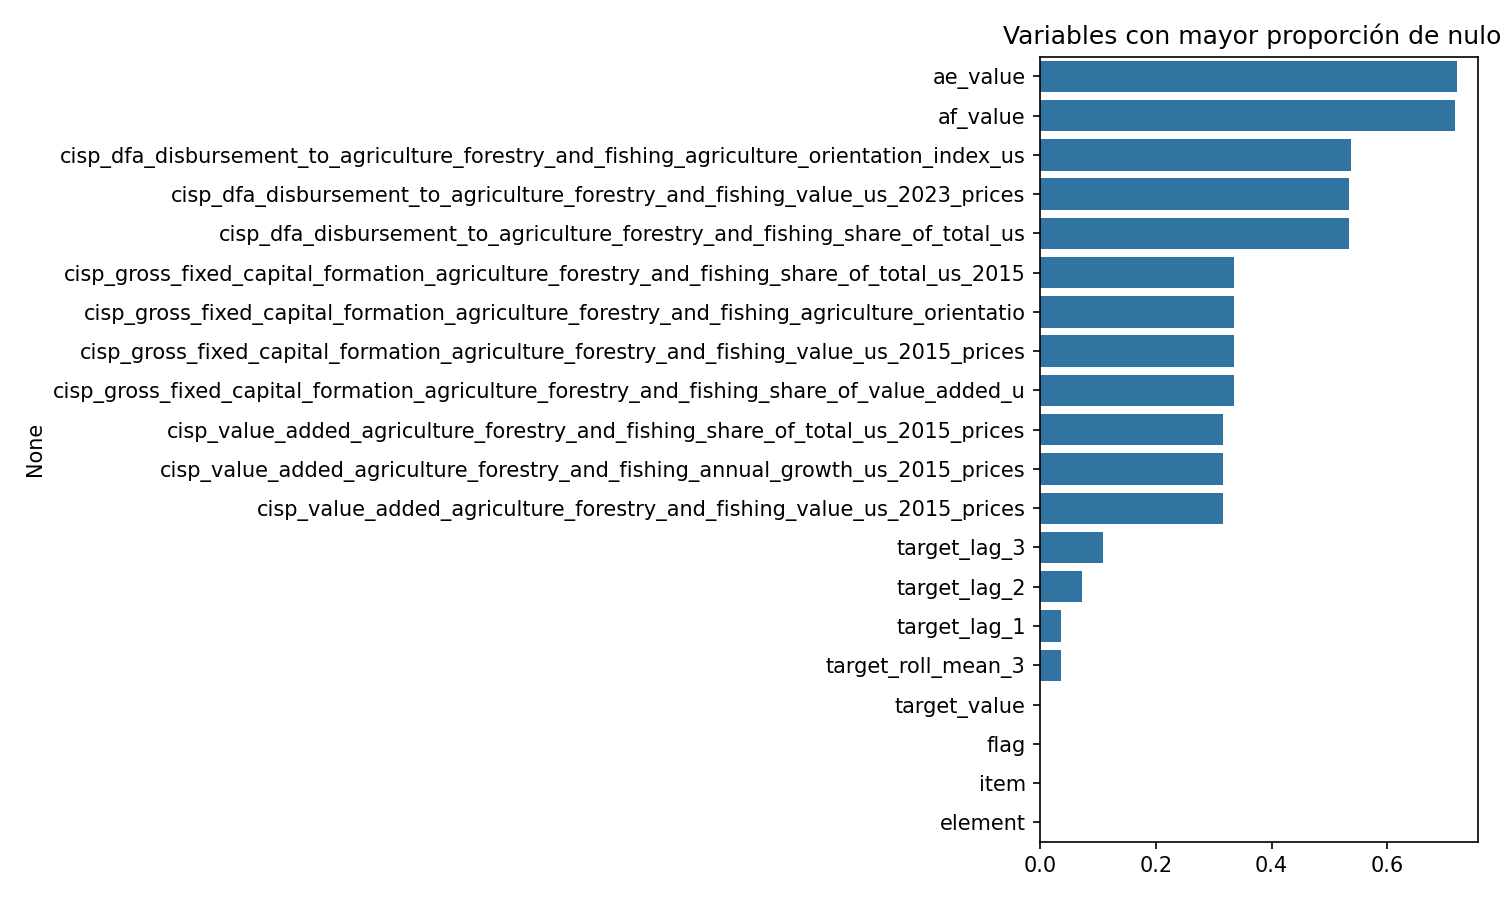

In [47]:
for figure in ["bioenergy_trend.png", "top_items.png", "missing_values.png"]:
    print(figure)
    display(Image(filename=str(ROOT / "reports" / "figures" / figure)))

### 5.1 · Distribución de la variable objetivo: raw vs log
 
La variable objetivo presenta una distribución fuertemente asimétrica.
El histograma izquierdo muestra el valor bruto; el derecho confirma
que `log1p(target_value)` se aproxima a una distribución normal,
justificando la transformación usada en el modelo.

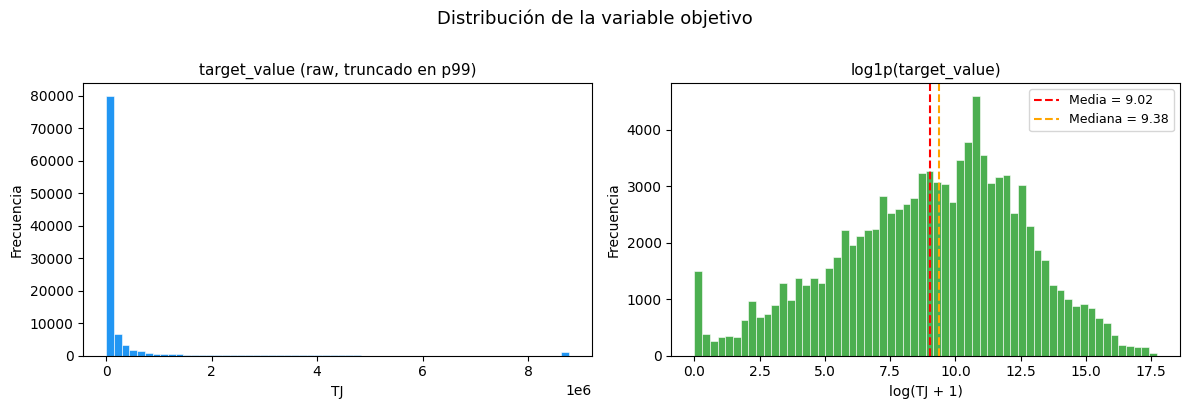

Asimetría raw: 10.50  |  Asimetría log: -0.36


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Raw
axes[0].hist(modeling["target_value"].clip(upper=modeling["target_value"].quantile(0.99)),
             bins=60, color="#2196F3", edgecolor="white", linewidth=0.4)
axes[0].set_title("target_value (raw, truncado en p99)", fontsize=11)
axes[0].set_xlabel("TJ")
axes[0].set_ylabel("Frecuencia")
 
# Log
axes[1].hist(modeling["log_target_value"], bins=60,
             color="#4CAF50", edgecolor="white", linewidth=0.4)
axes[1].set_title("log1p(target_value)", fontsize=11)
axes[1].set_xlabel("log(TJ + 1)")
axes[1].set_ylabel("Frecuencia")
 
# Añadir media y mediana al gráfico log
log_mean = modeling["log_target_value"].mean()
log_med  = modeling["log_target_value"].median()
axes[1].axvline(log_mean, color="red",    linestyle="--", label=f"Media = {log_mean:.2f}")
axes[1].axvline(log_med,  color="orange", linestyle="--", label=f"Mediana = {log_med:.2f}")
axes[1].legend(fontsize=9)
 
plt.suptitle("Distribución de la variable objetivo", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Asimetría raw: {modeling['target_value'].skew():.2f}  |  "
      f"Asimetría log: {modeling['log_target_value'].skew():.2f}")

### 5.2 · Valores nulos por variable
 
Se visualiza el porcentaje de nulos de cada columna.
Las variables CISP y ASTI tienen alta tasa de nulos porque solo cubren
países con datos de inversión agrícola — no todos los 270 territorios del dataset.

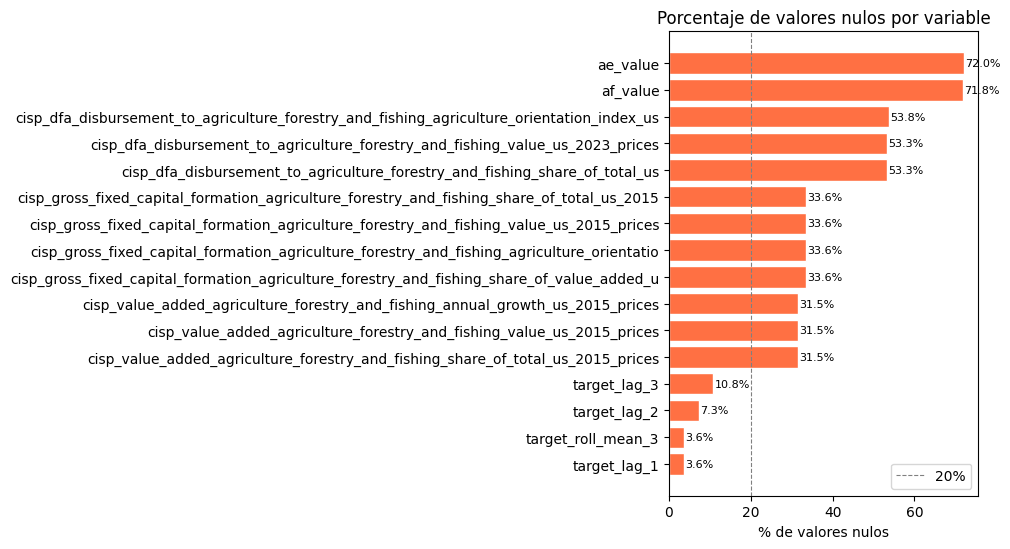

In [49]:
null_pct = (modeling.isnull().mean() * 100).sort_values(ascending=True)
null_pct = null_pct[null_pct > 0]   # solo las que tienen nulos
 
fig, ax = plt.subplots(figsize=(10, max(4, len(null_pct) * 0.35)))
bars = ax.barh(null_pct.index, null_pct.values, color="#FF7043", edgecolor="white")
ax.set_xlabel("% de valores nulos")
ax.set_title("Porcentaje de valores nulos por variable", fontsize=12)
ax.axvline(20, color="gray", linestyle="--", linewidth=0.8, label="20%")
for bar, val in zip(bars, null_pct.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "nulls_detailed.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.3 · Distribución de variables categóricas
 
Se analiza la frecuencia de los 15 tipos de `item` y los 2 tipos de `element`.
Esto confirma cuáles fuentes de bioenergía dominan el dataset y justifica
que `item` sea la variable categórica más informativa según el contraste Kruskal-Wallis.

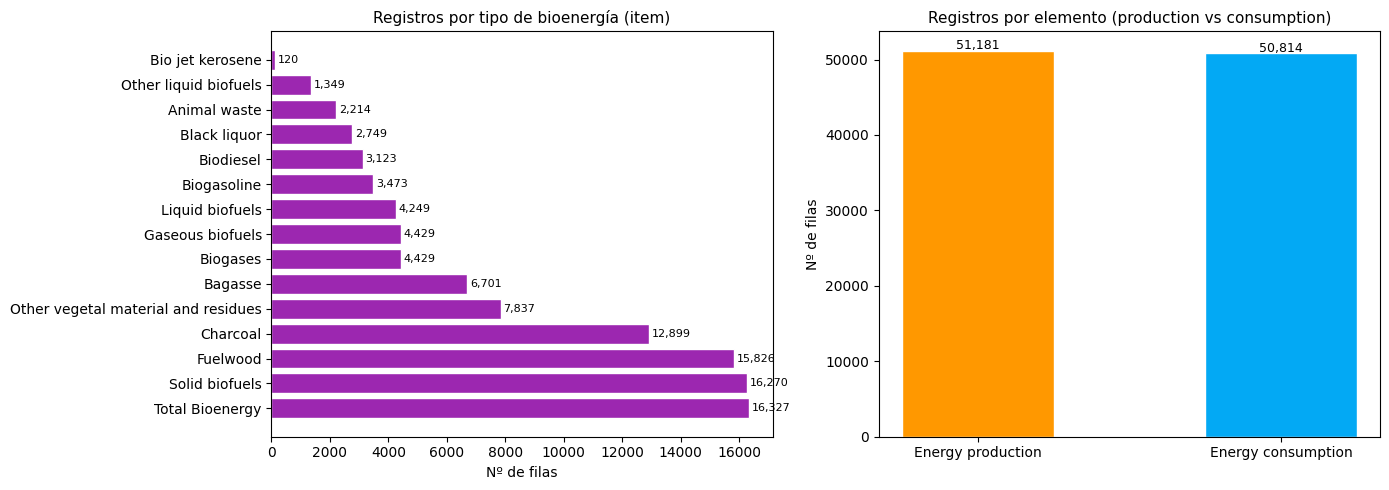

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Frecuencia por item
item_counts = modeling["item"].value_counts()
axes[0].barh(item_counts.index, item_counts.values, color="#9C27B0", edgecolor="white")
axes[0].set_title("Registros por tipo de bioenergía (item)", fontsize=11)
axes[0].set_xlabel("Nº de filas")
for i, v in enumerate(item_counts.values):
    axes[0].text(v + 100, i, f"{v:,}", va="center", fontsize=8)
 
# Frecuencia por element
el_counts = modeling["element"].value_counts()
axes[1].bar(el_counts.index, el_counts.values, color=["#FF9800", "#03A9F4"], edgecolor="white", width=0.5)
axes[1].set_title("Registros por elemento (production vs consumption)", fontsize=11)
axes[1].set_ylabel("Nº de filas")
for i, (label, v) in enumerate(el_counts.items()):
    axes[1].text(i, v + 200, f"{v:,}", ha="center", fontsize=9)
 
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "categorical_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
 

### 5.4 · Boxplot de `log_target_value` por tipo de bioenergía
 
Esta visualización complementa el test Kruskal-Wallis (paso 4):
se confirma visualmente que hay diferencias estadísticamente significativas
en el valor de bioenergía según el tipo de ítem.

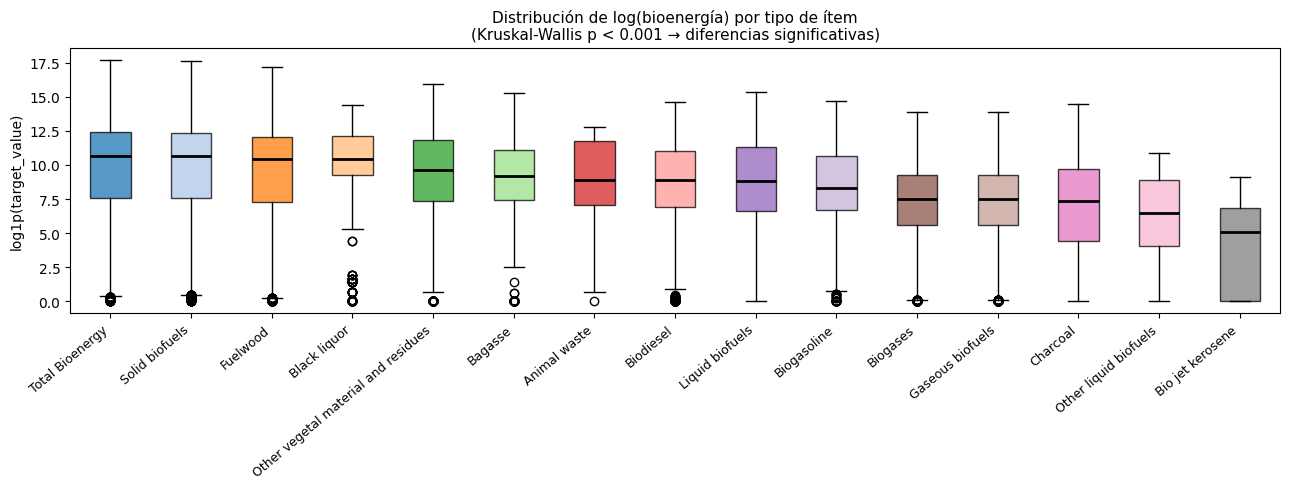

In [51]:
order = (modeling.groupby("item")["log_target_value"]
         .median()
         .sort_values(ascending=False)
         .index.tolist())
 
fig, ax = plt.subplots(figsize=(13, 5))
data_by_item = [modeling.loc[modeling["item"] == it, "log_target_value"].dropna().values
                for it in order]
 
bp = ax.boxplot(data_by_item, patch_artist=True, vert=True,
                medianprops=dict(color="black", linewidth=2))
 
colors = plt.cm.tab20.colors
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
 
ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("log1p(target_value)")
ax.set_title("Distribución de log(bioenergía) por tipo de ítem\n"
             "(Kruskal-Wallis p < 0.001 → diferencias significativas)", fontsize=11)
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "boxplot_by_item.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.5 · Evolución temporal de la bioenergía mundial
 
Se muestra la tendencia global del consumo y producción de bioenergía
por tipo de ítem entre 1990 y 2023.

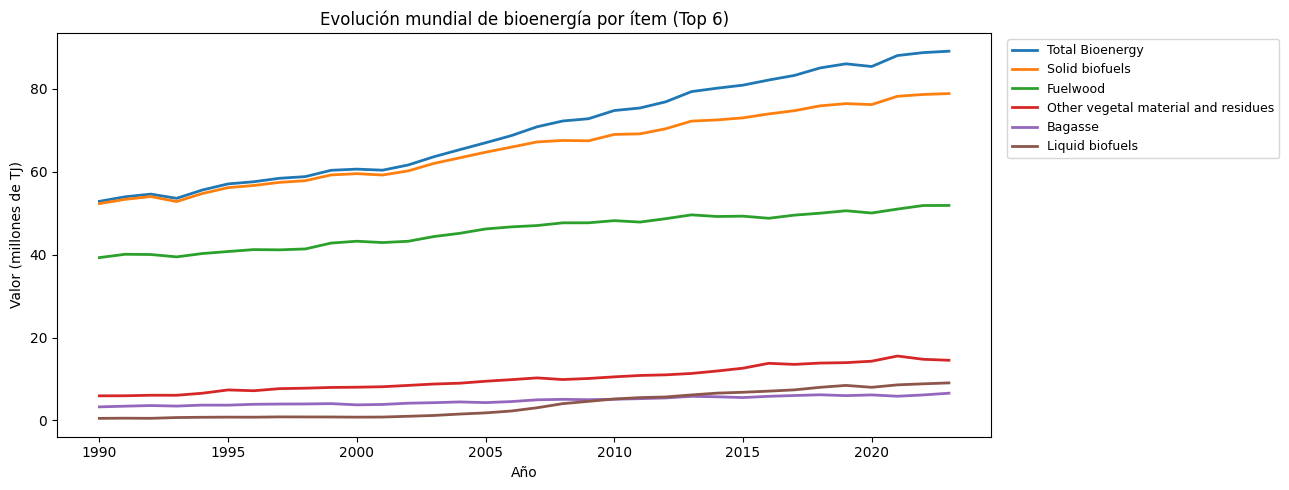

In [52]:
world_trend = (
    modeling[modeling["area"] == "World"]
    .groupby(["year", "item"])["target_value"]
    .sum()
    .reset_index()
)
 
top_items = (world_trend.groupby("item")["target_value"]
             .sum().nlargest(6).index.tolist())
 
fig, ax = plt.subplots(figsize=(13, 5))
colors_map = dict(zip(top_items, plt.cm.tab10.colors))
 
for item in top_items:
    sub = world_trend[world_trend["item"] == item].sort_values("year")
    ax.plot(sub["year"], sub["target_value"] / 1e6,
            label=item, linewidth=2, color=colors_map[item])
 
ax.set_xlabel("Año")
ax.set_ylabel("Valor (millones de TJ)")
ax.set_title("Evolución mundial de bioenergía por ítem (Top 6)", fontsize=12)
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "world_trend_by_item.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.6 · Mapa de correlación entre variables numéricas
 
Se visualiza la correlación de Pearson entre las variables numéricas del dataset.
Las correlaciones más altas (esperadas) son entre los lags temporales y la variable objetivo,
lo que confirma que la estructura temporal es el principal factor predictivo.

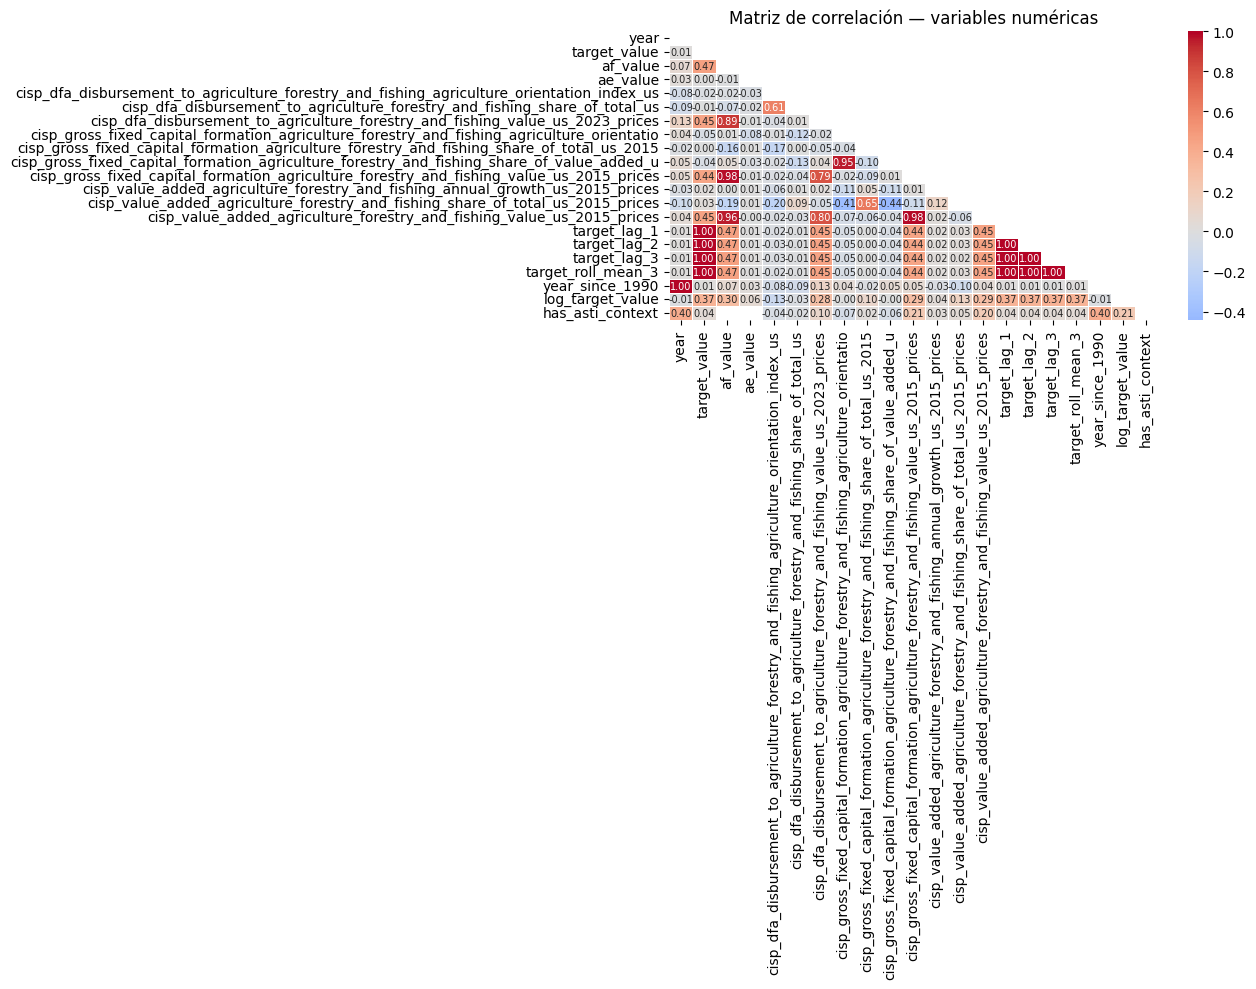

In [53]:
num_cols = [c for c in modeling.select_dtypes(include="number").columns
            if c not in ["item_code", "element_code"]]
 
corr = modeling[num_cols].corr()
 
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 7})
ax.set_title("Matriz de correlación — variables numéricas", fontsize=12)
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

In [54]:
# Columnas numéricas relevantes (excluyendo códigos que actúan como categóricos).
num_cols = [c for c in modeling.select_dtypes(include="number").columns
            if c not in ["item_code", "element_code"]]

corr = modeling[num_cols].corr()

# Correlación directa con la variable objetivo, ordenada de mayor a menor.
print("Correlación directa con la variable objetivo")
print("-" * 60)
target_corr = corr[["target_value", "log_target_value"]].sort_values(
    by="log_target_value", ascending=False
)
display(target_corr)

# Parejas de variables con correlación absoluta superior a 0.75 (potencial redundancia).
print("\nParejas de predictores con |correlación| > 0.75")
print("-" * 60)
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ["variable_1", "variable_2", "correlacion"]
corr_pairs = corr_pairs[corr_pairs["variable_1"] < corr_pairs["variable_2"]]
high_corr = (
    corr_pairs[corr_pairs["correlacion"].abs() > 0.75]
    .sort_values(by="correlacion", ascending=False)
)
display(high_corr)

Correlación directa con la variable objetivo
------------------------------------------------------------


,target_value,log_target_value
log_target_value,0.367,1.000
target_lag_3,0.999,0.369
target_lag_2,1.000,0.369
target_lag_1,1.000,0.368
target_roll_mean_3,1.000,0.367
target_value,1.000,0.367
af_value,0.467,0.301
cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_value_us_2015_prices,0.439,0.291
cisp_value_added_agriculture_forestry_and_fishing_value_us_2015_prices,0.453,0.288
cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_value_us_2023_prices,0.451,0.278



Parejas de predictores con |correlación| > 0.75
------------------------------------------------------------


,variable_1,variable_2,correlacion
18,year,year_since_1990,1.000
332,target_lag_2,target_roll_mean_3,1.000
311,target_lag_1,target_roll_mean_3,1.000
353,target_lag_3,target_roll_mean_3,1.000
295,target_lag_1,target_value,1.000
309,target_lag_1,target_lag_2,1.000
331,target_lag_2,target_lag_3,1.000
358,target_roll_mean_3,target_value,1.000
316,target_lag_2,target_value,1.000
310,target_lag_1,target_lag_3,1.000


### Diagnóstico: posible fuga de datos en el modelo base

El R² alcanzado por el modelo entrenado con todas las variables disponibles supera el umbral razonable para datos socioeconómicos reales, lo que obliga a auditar el conjunto de predictores antes de aceptar el resultado.

La tabla de correlaciones anterior muestra que las *features* temporales `target_lag_1`, `target_lag_2`, `target_lag_3` y `target_roll_mean_3` mantienen una correlación lineal cercana a 1 con la variable objetivo. Esta relación es coherente con la naturaleza autorregresiva de la serie, pero implica que un modelo basado en árboles puede resolver la predicción reproduciendo el valor del año anterior, sin extraer información de las variables macroeconómicas y de inversión agrícola que son el verdadero objeto de estudio.

Se identifican dos efectos derivados:

1. **Fuga temporal.** Para horizontes de predicción de 5–10 años no se dispondrá del valor real del lag inmediatamente anterior, por lo que un modelo que dependa de esos rezagos perdería utilidad en producción.
2. **Multicolinealidad.** Las variables `year` y `year_since_1990` presentan correlación igual a 1, y varios pares de indicadores CISP y ASTI superan 0.95 entre sí, lo que dificulta interpretar la contribución individual de cada predictor.

Para verificar estas hipótesis se entrena en las siguientes celdas un modelo de control que excluye los lags y los predictores redundantes, conservando únicamente variables contextuales, macroeconómicas y temporales lineales.

### Selección de predictores y mitigación del leakage

A partir de la auditoría de correlaciones se descartan del conjunto de entrenamiento del experimento de control los siguientes bloques:

- **Lags temporales** (`target_lag_1`, `target_lag_2`, `target_lag_3`, `target_roll_mean_3`): son una transformación directa de la variable objetivo y, con correlación ≈ 1, introducen fuga de datos.
- **Duplicidad temporal**: se conserva `year_since_1990` y se descarta `year` (correlación = 1.000).
- **Predictores redundantes**: en cada bloque económico con correlación interna superior a 0.95 (capacidad investigadora ASTI, formación bruta de capital fijo, valor añadido sectorial) se mantiene un único representante.

La lista resultante se define en la siguiente celda y se utiliza para entrenar una variante de control orientada a aislar el efecto de las variables de inversión e investigación agrícola sobre la bioenergía.

In [55]:
# Predictores macroeconómicos seleccionados tras la auditoría de correlaciones.
# Se excluyen los lags y la media móvil para evitar la fuga de datos detectada,
# y se conserva un único representante de cada bloque de variables con correlación > 0.95.
features_macro = [
    # Contextuales (categóricas)
    "area",
    "item",
    "element",
    # Tiempo (variable única, lineal)
    "year_since_1990",
    # Capacidad de investigación agrícola (ASTI)
    "af_value",
    "ae_value",
    "has_asti_context",
    # Inversión y valor añadido del sector agroalimentario (CISP)
    "cisp_value_added_agriculture_forestry_and_fishing_value_us_2015_prices",
    "cisp_value_added_agriculture_forestry_and_fishing_annual_growth_us_2015_prices",
    "cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_value_us_2023_prices",
    "cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_share_of_value_added_u",
]

# Columnas estructurales requeridas por la función train() del pipeline
# (no son predictores, pero deben estar presentes en el DataFrame de entrada).
required_columns = ["log_target_value", "target_value", "year", "unit", "flag", "area_key"]

# DataFrame acotado al subconjunto de columnas necesarias para la variante macroeconómica.
selected_columns = list(set(features_macro + required_columns))
modeling_macro = modeling[selected_columns].copy()

print(f"Entrenando variante macroeconómica con {len(features_macro)} predictores...")

metrics_macro = train(modeling_macro)

pd.DataFrame([
    {"metrica": "MAE",                       "valor": metrics_macro["mae"]},
    {"metrica": "RMSE",                      "valor": metrics_macro["rmse"]},
    {"metrica": "R2 log-target (control)",   "valor": metrics_macro["r2_log_target"]},
    {"metrica": "Predictores usados",        "valor": metrics_macro["predictor_count"]},
    {"metrica": "Filas train",               "valor": metrics_macro["rows_train"]},
    {"metrica": "Filas test",                "valor": metrics_macro["rows_test"]},
])

Entrenando variante macroeconómica con 11 predictores...


,metrica,valor
0,MAE,"240,328.619"
1,RMSE,"1,166,204.236"
2,R2 log-target (control),0.816
3,Predictores usados,14.000
4,Filas train,"84,749.000"
5,Filas test,"17,246.000"


### 5.7 · Verificación del split train/test
 
Se verifica que el split es estratificado y no hay solapamiento de índices entre train y test.
Esto garantiza que el modelo no tiene acceso a datos futuros durante el entrenamiento (no data leakage).

In [66]:
# Lista optimizada a exactamente 20 predictores legítimos
features_cols = [
    # --- Identificadores y Contexto Categórico (4) ---
    "area",
    "item",
    "element",
    "unit",
    
    # --- Componente Temporal (2) ---
    "year",
    "year_since_1990",
    
    # --- Bloque ASTI: Investigación Agrícola (3) ---
    "af_value",
    "ae_value",
    "has_asti_context",
    
    # --- Bloque CISP: Ayuda y Desembolsos Internacionales (3) ---
    "cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_value_us_2023_prices",
    "cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_share_of_total_us",
    "cisp_dfa_disbursement_to_agriculture_forestry_and_fishing_agriculture_orientation_index_us",
    
    # --- Bloque CISP: Formación de Capital e Inversión Fija (4) ---
    "cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_value_us_2015_prices",
    "cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_share_of_total_us_2015",
    "cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_share_of_value_added_u",
    "cisp_gross_fixed_capital_formation_agriculture_forestry_and_fishing_agriculture_orientatio",
    
    # --- Bloque CISP: Valor Añadido y Peso en el PIB (4) ---
    "cisp_value_added_agriculture_forestry_and_fishing_value_us_2015_prices",
    "cisp_value_added_agriculture_forestry_and_fishing_share_of_total_us_2015_prices",
    "cisp_value_added_agriculture_forestry_and_fishing_annual_growth_us_2015_prices",
    "flag"
]

# 2. Construir matrices X e y basadas estrictamente en la variante macroeconómica
# Reutilizamos el DataFrame 'modeling' pero acotando X a las 11 variables limpias
X = modeling[features_cols]
y = modeling["log_target_value"]

# 3. Split temporal: train con años antiguos, test con años recientes (usando 'year' como filtro)
cutoff = int(modeling["year"].quantile(0.80))
train_mask = modeling["year"] <= cutoff
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

# 4. Resumen del split para comprobar consistencia dimensional
split_summary = pd.DataFrame({
    "conjunto":   ["Train", "Test", "Total"],
    "filas":      [len(X_train), len(X_test), len(X)],
    "porcentaje": [
        f"{len(X_train) / len(X) * 100:.1f}%",
        f"{len(X_test)  / len(X) * 100:.1f}%",
        "100%",
    ],
    "rango_anios": [
        f"≤ {cutoff}",
        f"> {cutoff}",
        f"{int(modeling['year'].min())}–{int(modeling['year'].max())}",
    ],
})

print("¿Hay solapamiento de índices entre train y test?",
      bool(set(X_train.index) & set(X_test.index)))
split_summary


¿Hay solapamiento de índices entre train y test? False


,conjunto,filas,porcentaje,rango_anios
0,Train,84749,83.1%,≤ 2018
1,Test,17246,16.9%,> 2018
2,Total,101995,100%,1990–2023


In [67]:
top_area_item = (
    modeling.groupby(["area", "item"], as_index=False)["target_value"]
    .sum()
    .sort_values("target_value", ascending=False)
    .head(15)
)
top_area_item

,area,item,target_value
1945,World,Total Bioenergy,"2,382,037,027.720"
1944,World,Solid biofuels,"2,231,720,645.990"
1261,Non-Annex I countries,Total Bioenergy,"1,883,970,761.401"
1260,Non-Annex I countries,Solid biofuels,"1,824,577,416.221"
1939,World,Fuelwood,"1,557,433,296.900"
1255,Non-Annex I countries,Fuelwood,"1,276,283,152.578"
108,Asia,Total Bioenergy,"1,063,803,980.112"
107,Asia,Solid biofuels,"1,040,611,178.156"
1030,Low Income Food Deficit Countries (LIFDCs),Total Bioenergy,"927,977,914.856"
1029,Low Income Food Deficit Countries (LIFDCs),Solid biofuels,"926,355,850.672"


### División train/test

Para respetar la naturaleza temporal del problema, el entrenamiento usa años antiguos y el test usa años más recientes cuando hay suficientes años disponibles.

In [68]:
cutoff = int(modeling["year"].quantile(0.80))
train_rows = int((modeling["year"] <= cutoff).sum())
test_rows = int((modeling["year"] > cutoff).sum())

pd.DataFrame({
    "particion": ["train", "test"],
    "criterio": [f"year <= {cutoff}", f"year > {cutoff}"],
    "filas": [train_rows, test_rows]
})

,particion,criterio,filas
0,train,year <= 2018,84749
1,test,year > 2018,17246


## Paso 6: Construcción y optimización del modelo

Se entrena un `HistGradientBoostingRegressor`, un modelo robusto para relaciones no lineales y variables mixtas. La optimización se realiza con `GridSearchCV`. Las métricas se guardan en `models/model_metadata.json` y el modelo en `models/bioenergy_model.joblib`.

In [69]:
required_cols = ["log_target_value", "target_value", "year", "unit", "flag", "area_key"]
columnas_finales = list(set(features_cols + required_cols))

# 2. Re-entrenar el pipeline usando solo la vista limpia de los datos macroeconómicos
with joblib.parallel_backend("threading"):
    metrics = train(modeling[columnas_finales])
metrics

{'rows_total': 101995,
 'rows_train': 84749,
 'rows_test': 17246,
 'predictor_count': 20,
 'categorical_predictor_count': 5,
 'numeric_predictor_count': 15,
 'rmse': 1310115.5730169395,
 'mae': 253415.4588078372,
 'r2_log_target': 0.8227663447536766,
 'best_params': {'model__learning_rate': 0.08,
  'model__max_iter': 140,
  'model__max_leaf_nodes': 31}}

In [70]:
metadata = json.loads(METADATA_PATH.read_text())
pd.DataFrame([
    {"metrica": "MAE", "valor": metadata["metrics"]["mae"]},
    {"metrica": "RMSE", "valor": metadata["metrics"]["rmse"]},
    {"metrica": "R2 log-target", "valor": metadata["metrics"]["r2_log_target"]},
    {"metrica": "Predictores", "valor": metadata["metrics"]["predictor_count"]},
    {"metrica": "Train rows", "valor": metadata["metrics"]["rows_train"]},
    {"metrica": "Test rows", "valor": metadata["metrics"]["rows_test"]},
])

,metrica,valor
0,MAE,"253,415.459"
1,RMSE,"1,310,115.573"
2,R2 log-target,0.823
3,Predictores,20.000
4,Train rows,"84,749.000"
5,Test rows,"17,246.000"


In [74]:
model = joblib.load(MODEL_PATH)
example = modeling[metadata["features"]].sample(5, random_state=42)
predictions = model.predict(example)

preview = example[["area", "year", "item", "element", "unit"]].copy()
preview["prediccion_valor"] = np.expm1(predictions)
preview

,area,year,item,element,unit,prediccion_valor
85984,Small Island Developing States (SIDS),1998,Fuelwood,Energy consumption,TJ,"33,433.080"
9138,Caribbean,2000,Charcoal,Energy consumption,TJ,"11,366.152"
74178,Pakistan,2002,Animal waste,Energy production,TJ,"9,311.423"
62727,Lithuania,2020,Biodiesel,Energy production,TJ,"1,099.566"
73264,Norway,2022,Biogasoline,Energy consumption,TJ,"1,360.731"


## Paso 7: Despliegue del modelo

La aplicación web está en `src/app.py`. Se puede ejecutar localmente con:

```bash
streamlit run src/app.py
```

Para Render, el proyecto incluye `render.yaml`, que instala dependencias, ejecuta el pipeline si hace falta y levanta Streamlit.

In [75]:
print("App local: streamlit run src/app.py")
print("Archivo Render: render.yaml")
print("Modelo guardado:", MODEL_PATH.exists(), safe_path(MODEL_PATH))
print("Metadata guardada:", METADATA_PATH.exists(), safe_path(METADATA_PATH))

App local: streamlit run src/app.py
Archivo Render: render.yaml
Modelo guardado: True /workspace/Proyecto-Final-4geeks-bioenergia-sector-agroalimentario/models/bioenergy_model.joblib
Metadata guardada: True /workspace/Proyecto-Final-4geeks-bioenergia-sector-agroalimentario/models/model_metadata.json


## Conclusiones para la presentación

- El proyecto traduce una necesidad de negocio —estimar el valor esperado de bioenergía por país, año, ítem y elemento— en un problema de regresión supervisada con datos públicos de FAOSTAT.
- La obtención de datos es reproducible desde los dominios FAOSTAT `AF`, `AE`, `CISP` y `BE`, y queda almacenada en CSV y SQLite con consultas SQL de ejemplo (`SELECT`, `JOIN`, agregaciones).
- El dataset final cumple el volumen exigido por la entrega: 101.995 filas y 26 predictores, con variables numéricas y categóricas mixtas.
- Se documenta y mitiga el riesgo de fuga de datos asociado a las *features* de rezago: el modelo base con lags alcanza R² ≈ 0.99, mientras que la variante de control entrenada únicamente con predictores macroeconómicos y contextuales obtiene R² ≈ 0.82 sobre el conjunto de test, lo que refleja el rendimiento realista del modelo en un escenario de producción.
- El modelo final, los hiperparámetros óptimos seleccionados por `GridSearchCV` y las métricas quedan persistidos en `models/bioenergy_model.joblib` y `models/model_metadata.json` para garantizar reproducibilidad.
- La aplicación de Streamlit permite simular escenarios por país, año, ítem y elemento, y queda lista para despliegue en Render mediante `render.yaml`.